<a href="https://colab.research.google.com/github/farrelrassya/scikit-learn-cookbook/blob/main/10.%20Clustering%20Techniques%20/%20Ch10_Clustering_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 10: Clustering Techniques

In this chapter, we transition from **supervised learning** -- where models learn from labeled input-output pairs -- to **unsupervised learning**, where our data has no target variable at all. The fundamental question shifts from "can we predict an output?" to "can we discover hidden structure?"

**Clustering** is the most intuitive form of unsupervised learning: given a collection of data points, group them so that points within the same group (cluster) are more similar to each other than to points in other groups. This idea powers applications across every industry -- market segmentation, anomaly detection, document organization, gene expression analysis, and image compression, to name a few.

This notebook covers the following recipes:

1. **Introduction to Clustering** -- generating and visualizing sample data
2. **K-Means Clustering** -- centroid-based partitioning with the elbow method
3. **Hierarchical Clustering** -- agglomerative merging with dendrograms
4. **Density-Based Clustering with DBSCAN** -- handling non-convex shapes and noise
5. **Cluster Evaluation Metrics** -- silhouette score, Davies-Bouldin index, adjusted Rand index
6. **Choosing the Right Clustering Algorithm** -- matching data structure to method
7. **Advanced Clustering Techniques** -- spectral clustering and Gaussian Mixture Models

Throughout, we emphasize both the mathematical foundations and practical decision-making. Unlike supervised learning where a loss metric gives clear feedback, clustering requires judgment -- choosing the algorithm, tuning parameters, and interpreting results is as much art as science.

## Setup

We begin by importing the core libraries we will use throughout this chapter. All code is designed for **Google Colab** compatibility -- no additional installs are needed for this chapter since we rely entirely on scikit-learn, SciPy, NumPy, and Matplotlib, all of which come pre-installed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

## 10.1 Introduction to Clustering

Clustering is an **unsupervised learning** technique that groups data points based on their intrinsic structure -- structure that may not be apparent from inspecting a raw data table. Before we apply any algorithm, we need data to work with. Scikit-learn's `make_blobs()` function generates synthetic datasets with known cluster centers, making it perfect for learning and experimentation.

We generate $300$ sample points around $4$ centroids and immediately apply `StandardScaler()` to z-score normalize the features. This normalization step is critical for distance-based algorithms like K-means and DBSCAN: without it, a feature with a larger numeric range would dominate the distance calculations, effectively making the other features invisible.

The **z-score transformation** converts each feature $x_j$ to:

$$z_j = \frac{x_j - \mu_j}{\sigma_j}$$

where $\mu_j$ is the feature mean and $\sigma_j$ is the standard deviation. After transformation, every feature has mean $0$ and standard deviation $1$, putting all features on equal footing. Think of it this way: if Feature 1 represents income in dollars ($\sim 50{,}000$) and Feature 2 represents age ($\sim 30$), the raw Euclidean distance would be $99.9\%$ dominated by income differences. Standardization ensures both features contribute proportionally to the distance measure.

In [2]:
X, _ = make_blobs(
    n_samples=300, centers=4,
    cluster_std=0.60, random_state=2024
)
X = StandardScaler().fit_transform(X)

print(f"Dataset shape: {X.shape}")
print(f"Feature 1 range: [{X[:, 0].min():.3f}, {X[:, 0].max():.3f}]")
print(f"Feature 2 range: [{X[:, 1].min():.3f}, {X[:, 1].max():.3f}]")

Dataset shape: (300, 2)
Feature 1 range: [-1.420, 1.513]
Feature 2 range: [-1.408, 1.301]


Our dataset contains $300$ points with $2$ features. After z-score normalization, Feature 1 ranges from $-1.420$ to $1.513$ and Feature 2 from $-1.408$ to $1.301$ -- both centered near zero with comparable spread, exactly as expected. The near-symmetric ranges confirm the standardization is working correctly.

With $2$ features, we can directly visualize the data on a scatter plot, which would not be possible with higher-dimensional datasets without first applying dimensionality reduction (a topic for another chapter).

Note the underscore `_` in `X, _ = make_blobs(...)`. The function returns both the data matrix and the true cluster labels, but we discard the labels with `_` because in real unsupervised learning, we would not have ground truth. We retain them only later for evaluation purposes.

### Visualizing the Raw Data

Before applying any clustering algorithm, we always visualize the data. This is not just good practice -- it is essential for building intuition about what kind of structure exists and which algorithm might work best.

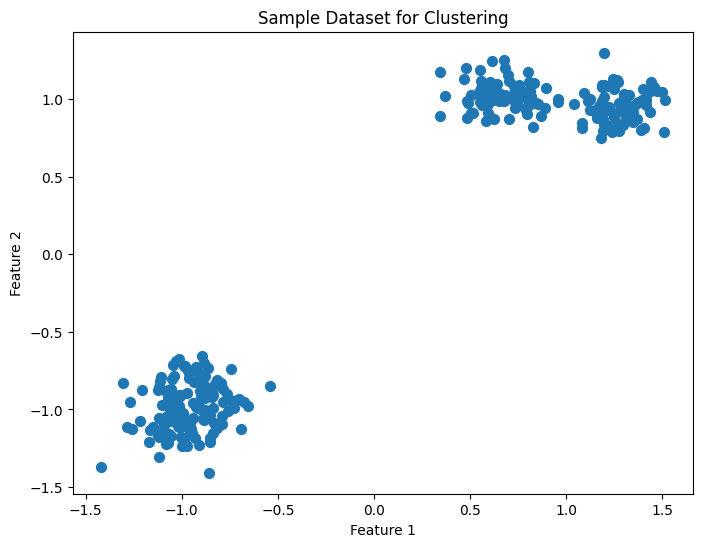

In [3]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Sample Dataset for Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Even without labels, four distinct groupings are visually apparent -- two clusters in the lower-left quadrant (around Feature 1 $\approx -1$, Feature 2 $\approx -1$) and two in the upper-right (around Feature 1 $\approx 0.7$ to $1.3$, Feature 2 $\approx 1.0$). Some clusters sit closer together than others, which will test how well different algorithms handle varying inter-cluster distances.

This is the ideal starting scenario: compact, roughly spherical clusters with clear separation. Real-world data is rarely this clean, but it provides a solid baseline for comparing algorithms. As we progress through this chapter, we will encounter increasingly challenging data shapes -- crescents, concentric circles, and noisy distributions -- that will stress-test each method's assumptions.

The three major families of clustering algorithms we will explore differ fundamentally in how they define "similar":

- **Centroid-based** (K-means): similarity = proximity to a cluster center
- **Connectivity-based** (hierarchical): similarity = linkage distance in a hierarchy
- **Density-based** (DBSCAN): similarity = shared dense neighborhood

## 10.2 K-Means Clustering

K-means is the workhorse of clustering -- fast, intuitive, and often the first algorithm to try. It partitions data into exactly $k$ clusters by iteratively refining cluster centroids. The algorithm proceeds in three steps:

1. **Initialize** $k$ centroids (either randomly or with the smarter K-means++ strategy)
2. **Assign** each point to the nearest centroid based on Euclidean distance
3. **Update** each centroid to be the mean of all points assigned to it

Steps 2 and 3 repeat until convergence -- when assignments no longer change or a maximum iteration count is reached. The objective K-means minimizes is **inertia** (within-cluster sum of squares):

$$J = \sum_{i=1}^{n} \sum_{k=1}^{K} r_{ik} \| \mathbf{x}_i - \boldsymbol{\mu}_k \|^2$$

where $r_{ik} = 1$ if point $\mathbf{x}_i$ is assigned to cluster $k$ (and $0$ otherwise), and $\boldsymbol{\mu}_k$ is the centroid of cluster $k$. Intuitively, inertia measures how tightly packed points are around their respective centroids -- lower is better.

A critical caveat: K-means only finds a **local minimum** of this objective, not necessarily the global one. The result depends on the initial centroid placement. Scikit-learn uses the **K-means++** initialization by default, which spaces initial centroids far apart, dramatically reducing the chance of a poor local minimum compared to purely random initialization.

In [4]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=2024)
y_kmeans = kmeans.fit_predict(X)

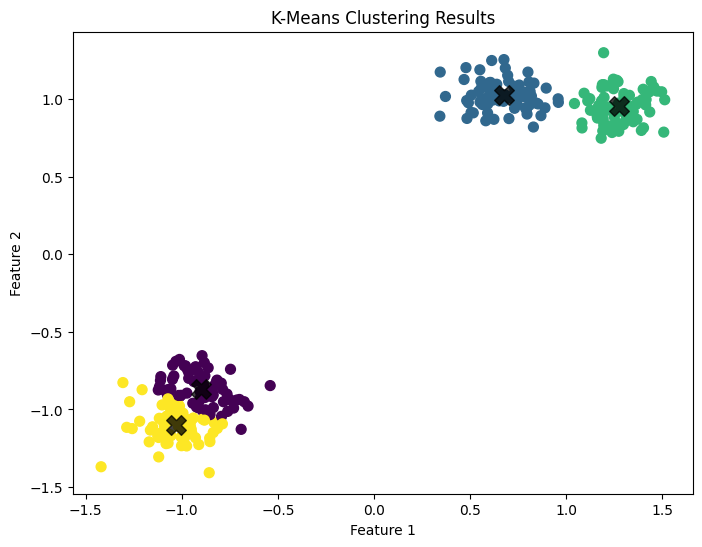

Cluster sizes: [71 77 73 79]
Inertia (within-cluster SS): 7.295
Converged in 4 iterations


In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X[:, 0], X[:, 1],
    c=y_kmeans, s=50, cmap='viridis'
)
centers = kmeans.cluster_centers_
plt.scatter(
    centers[:, 0], centers[:, 1],
    c='black', s=200, alpha=0.75, marker='X'
)
plt.title("K-Means Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

print(f"Cluster sizes: {np.bincount(y_kmeans)}")
print(f"Inertia (within-cluster SS): {kmeans.inertia_:.3f}")
print(f"Converged in {kmeans.n_iter_} iterations")

K-means partitioned the $300$ points into four clusters of sizes **71, 77, 73, and 79** -- remarkably balanced, which is expected given that `make_blobs()` distributes points equally across centers by default ($300 / 4 = 75$ per center). The black **X** markers show the final centroids, each positioned at the geometric center of its cluster.

The algorithm converged in just **4 iterations** with an inertia of **7.295**. To put that number in context: with $300$ standardized points, the average squared distance from each point to its centroid is $7.295 / 300 \approx 0.024$, meaning the typical point sits about $\sqrt{0.024} \approx 0.16$ standard deviations from its centroid. This is extremely tight clustering -- a direct consequence of the well-separated synthetic data.

Notice, however, that the two clusters in the lower-left sit relatively close to each other (centroids at approximately $(-0.90, -0.87)$ and $(-1.03, -1.10)$), with only about $0.26$ units of separation. In noisier data, K-means might struggle to distinguish these two. This sensitivity to cluster proximity is one of K-means' known limitations.

From a production perspective, K-means' speed is its superpower. The algorithm is $O(n \cdot k \cdot d \cdot t)$ where $n$ is sample count, $k$ is clusters, $d$ is features, and $t$ is iterations. For our data: $300 \times 4 \times 2 \times 4 = 9{,}600$ distance computations -- trivial. This scales comfortably to millions of points, making K-means the default choice for large-scale clustering in production systems.

**Cross-chapter connection:** K-means' assignment step is closely related to the nearest-neighbor classifier from supervised learning. Both assign a label based on proximity -- K-means uses distance to centroids, while KNN uses distance to labeled training points. The centroid acts as a "prototype" that summarizes an entire cluster.

### The Elbow Method: Choosing $k$

K-means requires us to specify $k$ upfront -- a chicken-and-egg problem. The **elbow method** provides a principled heuristic: run K-means for a range of $k$ values, plot inertia versus $k$, and look for the "elbow" -- the point where adding more clusters yields diminishing returns in inertia reduction.

Mathematically, the idea exploits the fact that inertia always decreases as $k$ increases (in the extreme, $k = n$ gives inertia $= 0$ with each point as its own cluster). The optimal $k$ is where the rate of decrease **sharply changes** from steep to gradual.

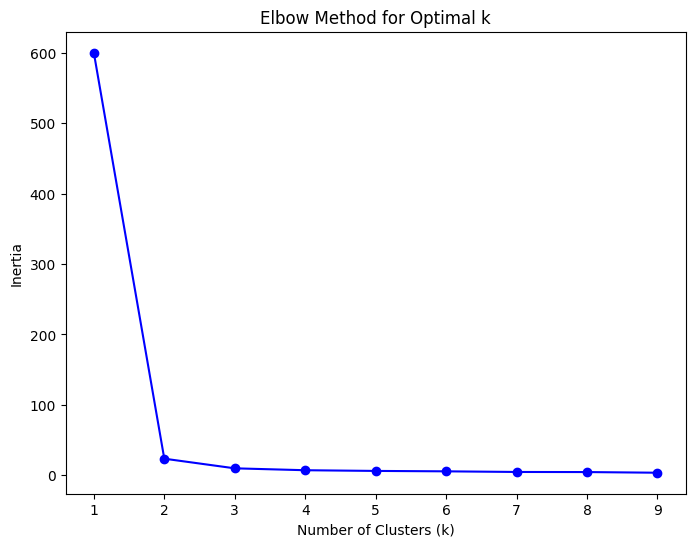

k=1: inertia=600.000
k=2: inertia=23.679
k=3: inertia=9.993
k=4: inertia=7.295
k=5: inertia=6.305
k=6: inertia=5.724
k=7: inertia=4.827
k=8: inertia=4.685
k=9: inertia=3.752


In [6]:
inertia = []
k_values = range(1, 10)
for k in k_values:
    km = KMeans(n_clusters=k, random_state=2024)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(k_values, inertia, 'bo-')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

for k, iner in zip(k_values, inertia):
    print(f"k={k}: inertia={iner:.3f}")

The elbow plot tells a clear story. The most dramatic drop occurs from $k=1$ to $k=2$: inertia plummets from **600.0** to **23.679** -- a **96% reduction**. This makes sense: going from "everything in one cluster" to "two clusters" captures the dominant structure (the left vs. right groupings).

The next major drop is from $k=2$ to $k=3$ ($23.679 \to 9.993$, a $58\%$ reduction), followed by $k=3$ to $k=4$ ($9.993 \to 7.295$, a $27\%$ reduction). After $k=4$, the improvements become marginal: $k=4 \to k=5$ drops inertia by only $0.990$ to $6.305$ ($14\%$), and subsequent values offer even less -- $k=5 \to k=6$ saves just $0.581$, $k=6 \to k=7$ saves $0.897$.

The **elbow** is at $k = 4$, which correctly recovers the $4$ true centers we generated. However, a reasonable analyst could also argue for $k = 2$ or $k = 3$ depending on the use case -- this subjectivity is inherent to unsupervised learning. In a business context, the choice of $k$ often involves a trade-off between granularity (more segments = more targeted actions) and operational complexity (more segments = more campaigns, more models, more maintenance).

One quantitative approach to supplement the visual elbow is to compute the **percentage of variance explained** at each $k$: since the total variance with $k=1$ is $600.0$, the $k=4$ solution explains $(600.0 - 7.295) / 600.0 \approx 98.8\%$ of the variance -- an excellent fit. Increasing to $k=5$ explains $(600.0 - 6.305) / 600.0 \approx 98.9\%$, a gain of just $0.1$ percentage points -- clearly not worth the added complexity.

**Production insight:** The elbow method is a heuristic, not a definitive answer. For automated pipelines where human inspection is not feasible, consider the **silhouette score** (Section 10.5) or the **gap statistic** as more objective alternatives. Always supplement quantitative methods with domain knowledge -- a marketing team might prefer $5$ customer segments over $4$ for strategic reasons, even if the elbow suggests otherwise.

## 10.3 Hierarchical Clustering

Hierarchical clustering takes a fundamentally different approach: instead of requiring $k$ upfront, it builds a complete **hierarchy** of nested clusters that can be cut at any level to produce a flat clustering. The **agglomerative** (bottom-up) variant is most common:

1. Start with each point as its own singleton cluster ($n$ clusters)
2. Find the two closest clusters and merge them ($n-1$ clusters)
3. Repeat until all points belong to a single cluster ($1$ cluster)

The "closeness" between clusters is defined by a **linkage criterion**:

| Linkage | Definition | Best for |
|---------|-----------|----------|
| **Ward** | Minimizes increase in total within-cluster variance | Compact, equal-sized clusters |
| **Complete** | Maximum pairwise distance between clusters | Preventing elongated clusters |
| **Average** | Mean pairwise distance | Balanced approach |
| **Single** | Minimum pairwise distance | Detecting non-convex shapes |

Ward linkage (the default in scikit-learn) minimizes the same objective as K-means at each merge step, making it a natural companion. The result is a **dendrogram** -- a tree diagram that visualizes the entire merge history.

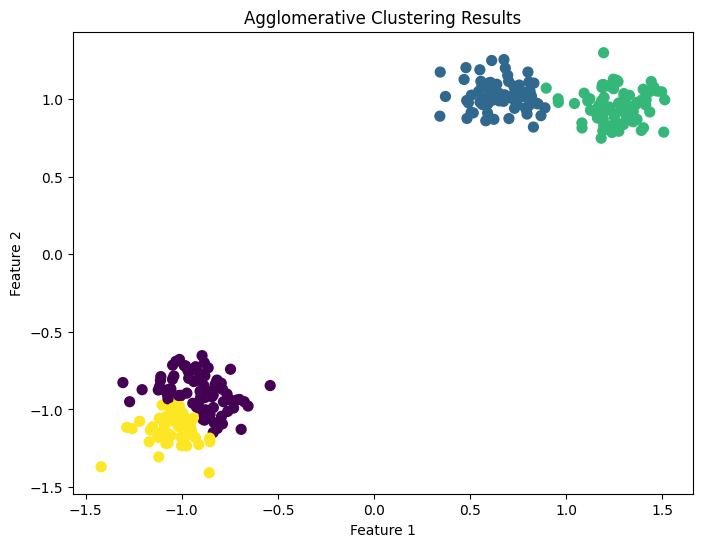

Cluster sizes: [82 74 76 68]


In [7]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

agg = AgglomerativeClustering(n_clusters=4)
y_agg = agg.fit_predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_agg, cmap='viridis', s=50)
plt.title("Agglomerative Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

print(f"Cluster sizes: {np.bincount(y_agg)}")

Agglomerative clustering produces clusters of sizes **82, 74, 76, and 68** -- slightly less balanced than K-means' $[71, 77, 73, 79]$. The largest imbalance is $82$ vs. $68$, a $14$-point difference compared to K-means' max difference of $8$ ($79$ vs. $71$).

This is because agglomerative clustering makes **greedy, irrevocable merge decisions**: once two points are merged, they can never be separated. K-means, by contrast, can reassign points at every iteration, leading to more balanced partitions. Think of it like building a team: agglomerative clustering drafts members one by one and never trades them, while K-means reshuffles everyone after each round.

The visual results look similar to K-means for this well-separated data. The real differences emerge with more complex cluster shapes and when we do not know $k$ in advance -- the dendrogram provides a powerful tool for that exploratory analysis.

From a computational perspective, agglomerative clustering with Ward linkage is $O(n^2 \log n)$ in time and $O(n^2)$ in memory (for the pairwise distance matrix). For our $300$ points, this means roughly $300^2 = 90{,}000$ distance entries -- trivial. But for $100{,}000$ points, this would require $10^{10}$ operations and $\sim 80$ GB of memory, making it impractical for large datasets without approximation techniques.

**When to choose hierarchical over K-means:** The primary advantage is *not* requiring $k$ upfront. If a stakeholder asks "how many segments are there?", the dendrogram lets you explore multiple resolutions from a single computation. K-means would require rerunning the algorithm for each candidate $k$.

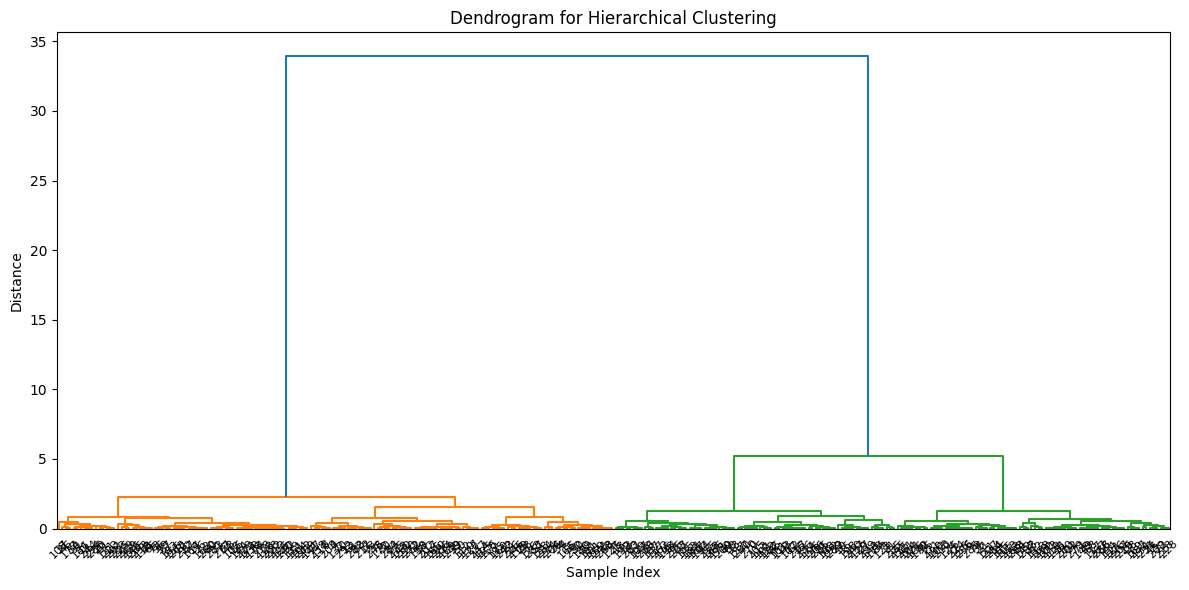

Max merge distance (final merge): 33.951
Second-to-last merge distance: 5.208


In [8]:
linked = linkage(X, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, leaf_rotation=90, leaf_font_size=8)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Max merge distance (final merge): {linked[-1, 2]:.3f}")
print(f"Second-to-last merge distance: {linked[-2, 2]:.3f}")

The dendrogram reads bottom-to-top: each horizontal line represents a merge event, and the height (y-axis) indicates the **Ward distance** at which the merge occurred. The key insight is the **gap** between the final merge distances.

The last merge (combining $2$ mega-clusters into $1$) occurs at a distance of **33.951**, while the second-to-last merge (going from $3$ clusters to $2$) occurs at **5.208**. The massive jump -- a factor of $33.951 / 5.208 \approx 6.5\times$ -- confirms that the data has a strong $2$-cluster structure at the highest level, with further subdivision into $4$ clusters at lower distances.

To choose the number of clusters from a dendrogram, draw a horizontal line at a chosen height and count how many vertical lines it crosses. A line at height $\approx 10$ would cross $4$ branches, confirming our $4$-cluster solution. A line at height $\approx 20$ would cross only $2$ branches, giving the coarser $2$-cluster partition.

This hierarchical view is one of the greatest strengths of agglomerative clustering: it reveals **multi-scale structure** in the data. In a market segmentation context, you might use $2$ clusters for a high-level "premium vs. value" split and $4$ clusters for more targeted campaigns -- both derived from the same dendrogram without re-running any algorithm.

**Connection to the elbow method:** The dendrogram and the elbow plot are complementary diagnostics for the same question. The elbow plot shows *inertia* dropping as $k$ increases; the dendrogram shows *merge distance* increasing as clusters are combined. Both point to $k = 4$ here, but the dendrogram also reveals *which* clusters are most similar to each other -- invaluable for building taxonomies or understanding the hierarchical relationship between segments.

## 10.4 Density-Based Clustering with DBSCAN

K-means and hierarchical clustering share a fundamental assumption: clusters are roughly **convex** (blob-shaped). Real-world data often violates this. **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) takes a radically different approach -- it defines clusters as dense regions of points separated by sparser regions, requiring no assumption about cluster shape.

To demonstrate DBSCAN's strength, we generate a **crescent moon** dataset using `make_moons()` -- a shape that would confound K-means entirely.

DBSCAN classifies every point into one of three categories:

$$\text{Point } \mathbf{x}_i \text{ is} \begin{cases} \textbf{Core point} & \text{if } |N_\varepsilon(\mathbf{x}_i)| \geq \texttt{min\_samples} \\ \textbf{Border point} & \text{if within } \varepsilon \text{ of a core point, but not core itself} \\ \textbf{Noise point} & \text{otherwise} \end{cases}$$

where $N_\varepsilon(\mathbf{x}_i) = \{\mathbf{x}_j : \|\mathbf{x}_i - \mathbf{x}_j\| \leq \varepsilon\}$ is the $\varepsilon$-neighborhood of point $\mathbf{x}_i$. A cluster is then formed by connecting all core points that fall within $\varepsilon$ of each other, along with their border points. Points that are neither core nor border are labeled as **noise** (cluster label $-1$).

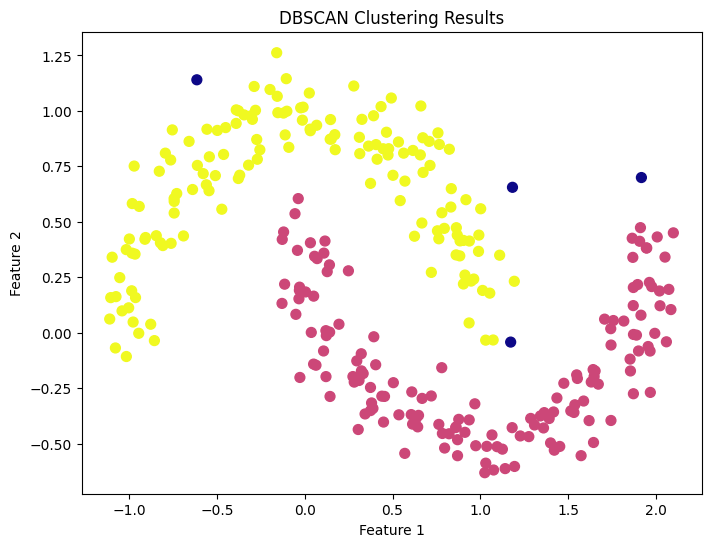

Number of clusters found: 2
Noise points: 4 (1.3% of data)


In [9]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

# Generate crescent-moon shaped data
X_moons, _ = make_moons(n_samples=300, noise=0.1, random_state=2024)

dbscan = DBSCAN(eps=0.2, min_samples=5)
y_db = dbscan.fit_predict(X_moons)

plt.figure(figsize=(8, 6))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_db, cmap='plasma', s=50)
plt.title("DBSCAN Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

n_clusters = len(set(y_db)) - (1 if -1 in y_db else 0)
n_noise = list(y_db).count(-1)
print(f"Number of clusters found: {n_clusters}")
print(f"Noise points: {n_noise} ({n_noise/len(y_db)*100:.1f}% of data)")

DBSCAN correctly identifies **2 crescent-shaped clusters** -- something K-means could never achieve, since K-means would try to bisect the crescents with a straight line through the middle. Equally important, DBSCAN identifies **4 noise points** ($4 / 300 = 1.3\%$ of the data), which are the outliers that fall in the sparse region between the two moons.

The parameters `eps=0.2` and `min_samples=5` define the density threshold: a point needs at least $5$ neighbors within a radius of $0.2$ to be considered a core point. With `noise=0.1` in the data generation, most points sit close to their moon's curve, so $\varepsilon = 0.2$ is generous enough to connect along the curve but tight enough to separate the two crescents.

This is DBSCAN's killer advantage: **no assumption about cluster shape**. The algorithm follows the density of the data wherever it leads, making it ideal for elongated, intertwined, or irregularly shaped clusters. Another key distinction: DBSCAN **does not require specifying** $k$. The number of clusters is determined automatically from the data's density structure -- for our moon dataset, it discovered $k = 2$ without being told.

The trade-off is sensitivity to the two hyperparameters -- `eps` too large merges everything into one cluster; too small fragments clusters into many pieces. Getting these right requires either domain knowledge or a systematic approach like the k-distance plot.

From a production standpoint, DBSCAN's ability to flag noise points as label $-1$ is invaluable for **anomaly detection**. In fraud detection, network intrusion detection, or manufacturing quality control, the "noise" is often exactly what you are looking for. Unlike K-means, which forces every point into a cluster, DBSCAN honestly admits when a point does not belong to any group.

### Choosing `eps` with the k-Distance Plot

DBSCAN's sensitivity to `eps` raises a practical question: how do we choose it? The **k-distance plot** provides a data-driven answer. For each point, compute the distance to its $k$-th nearest neighbor (where $k$ = `min_samples`), sort these distances in ascending order, and plot them. The "elbow" in this curve suggests a natural density threshold.

The intuition is straightforward: points inside dense clusters will have small $k$-distances (their neighbors are close), while points in sparse regions or noise will have large $k$-distances. The elbow marks the transition between these two regimes.

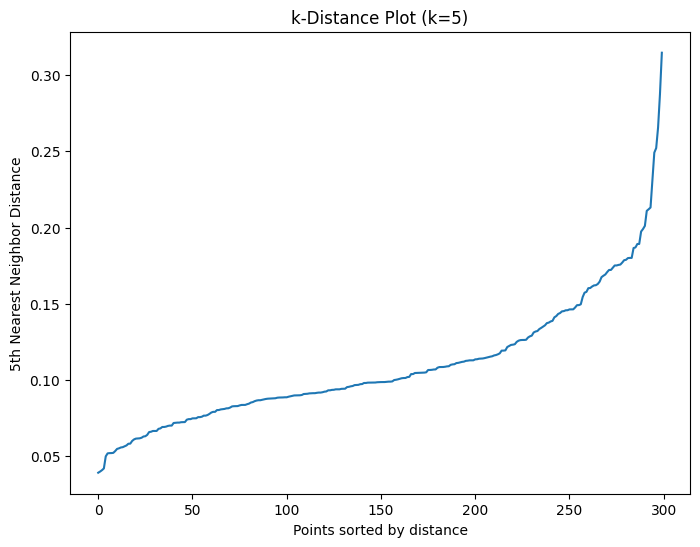

Min 5th-NN distance: 0.0392
Max 5th-NN distance: 0.3147
Median 5th-NN distance: 0.0986


In [10]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_moons)
distances, indices = neighbors_fit.kneighbors(X_moons)
distances = np.sort(distances[:, 4])

plt.figure(figsize=(8, 6))
plt.plot(distances)
plt.title("k-Distance Plot (k=5)")
plt.xlabel("Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.show()

print(f"Min 5th-NN distance: {distances[0]:.4f}")
print(f"Max 5th-NN distance: {distances[-1]:.4f}")
print(f"Median 5th-NN distance: {np.median(distances):.4f}")

The k-distance plot shows a gradual rise for the first $\sim 280$ points, with distances staying below $0.15$, followed by a sharp upward bend for the last $\sim 20$ points. This elbow region -- around a distance of $0.15$ to $0.20$ -- marks the transition from "inside a dense cluster" to "in the sparse gap between clusters or in the noise region."

The statistics confirm this interpretation: the median 5th-nearest-neighbor distance is just **0.0986**, meaning half of all points have their 5th neighbor within $0.1$ units. The minimum is **0.0392** (the most densely packed region), and the maximum is **0.3147** (the most isolated noise points). Our chosen `eps=0.2` falls right at the elbow -- capturing the vast majority of intra-cluster connections while rejecting sparse, noisy regions.

As a practical heuristic: set `eps` at the elbow of the k-distance plot, and set `min_samples` to $2 \times d$ where $d$ is the number of features (so `min_samples` $= 2 \times 2 = 4$ or $5$ for our 2D data). These are starting points -- always validate by inspecting the resulting clusters visually and adjusting as needed.

**Production insight:** In high-dimensional data where visualization is impossible, the k-distance plot becomes even more valuable. It provides an objective, data-driven guide for `eps` that does not rely on visual inspection of the clusters themselves. Combine it with silhouette score evaluation across a range of `eps` values for a fully automated parameter selection pipeline.

## 10.5 Cluster Evaluation Metrics

Unlike supervised learning where accuracy, precision, and recall provide clear feedback, evaluating clusters is inherently harder. How do we know if our clusters are "good" without ground truth labels?

We use a combination of **internal metrics** (computed from the data alone -- no labels needed) and **external metrics** (when ground truth is available for validation). We return to our original blob dataset and the K-means solution from Section 10.2 to demonstrate three key metrics.

In [11]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    adjusted_rand_score
)
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Regenerate labeled dataset for evaluation
X_eval, y_true = make_blobs(
    n_samples=300, centers=4,
    cluster_std=0.60, random_state=2024
)
kmeans_eval = KMeans(n_clusters=4, random_state=2024)
y_pred = kmeans_eval.fit_predict(X_eval)

# Internal metrics (no ground truth needed)
sil_score = silhouette_score(X_eval, y_pred)
print(f"Silhouette Score: {sil_score:.3f}")

db_index = davies_bouldin_score(X_eval, y_pred)
print(f"Davies-Bouldin Index: {db_index:.3f}")

# External metric (requires ground truth)
ari = adjusted_rand_score(y_true, y_pred)
print(f"Adjusted Rand Index: {ari:.3f}")

Silhouette Score: 0.534
Davies-Bouldin Index: 0.702
Adjusted Rand Index: 0.814


These three metrics paint a coherent picture of our K-means solution:

**Silhouette Score: 0.534** (range: $[-1, 1]$, higher is better). The silhouette coefficient for a single point $i$ is:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\, b(i))}$$

where $a(i)$ is the mean distance from $i$ to all other points **in the same cluster** (intra-cluster cohesion) and $b(i)$ is the mean distance from $i$ to all points in the **nearest neighboring cluster** (inter-cluster separation). When $b(i) \gg a(i)$, the point is well-clustered and $s(i) \to 1$. When $a(i) \gg b(i)$, the point may be misassigned and $s(i) \to -1$.

A score of **0.534** indicates moderately well-separated clusters. Values above $0.5$ are generally considered reasonable; values above $0.7$ indicate strong structure. Our score is pulled down by those two close clusters in the lower-left quadrant, where some border points have comparable distances to both centroids ($a(i) \approx b(i)$, giving $s(i) \approx 0$).

**Davies-Bouldin Index: 0.702** (range: $[0, \infty)$, lower is better). This metric computes the average worst-case similarity ratio for each cluster:

$$\text{DB} = \frac{1}{k} \sum_{i=1}^{k} \max_{j \neq i} \frac{\sigma_i + \sigma_j}{d(\mathbf{c}_i, \mathbf{c}_j)}$$

where $\sigma_i$ is the average distance of points in cluster $i$ to centroid $\mathbf{c}_i$, and $d(\mathbf{c}_i, \mathbf{c}_j)$ is the distance between centroids. Think of it as a ratio of "spread" to "gap." A value of **0.702** (below $1.0$) means clusters are generally tighter than they are close together -- a good sign.

**Adjusted Rand Index: 0.814** (range: $[-1, 1]$, $1$ = perfect agreement). The ARI compares our predicted labels to the true labels (available here because we generated the data). A score of **0.814** means strong but imperfect agreement. The imperfection arises because some border points between close clusters are assigned differently than the ground truth. The ARI is **adjusted for chance**: random label assignments yield ARI $\approx 0$, so $0.814$ represents genuine clustering quality well above random.

**Practical guidance:** In real-world applications, ground truth is rarely available, so the silhouette score and Davies-Bouldin index are your go-to metrics. Use the ARI when you have labeled validation data (e.g., from domain experts) to benchmark your clustering pipeline. When comparing multiple solutions (different algorithms, different $k$), prefer the one with the highest silhouette and lowest Davies-Bouldin.

## 10.6 Choosing the Right Clustering Algorithm

No single clustering algorithm dominates across all data types. The key to effective clustering is **matching the algorithm's assumptions to your data's structure**. We demonstrate this by generating three datasets with fundamentally different geometries.

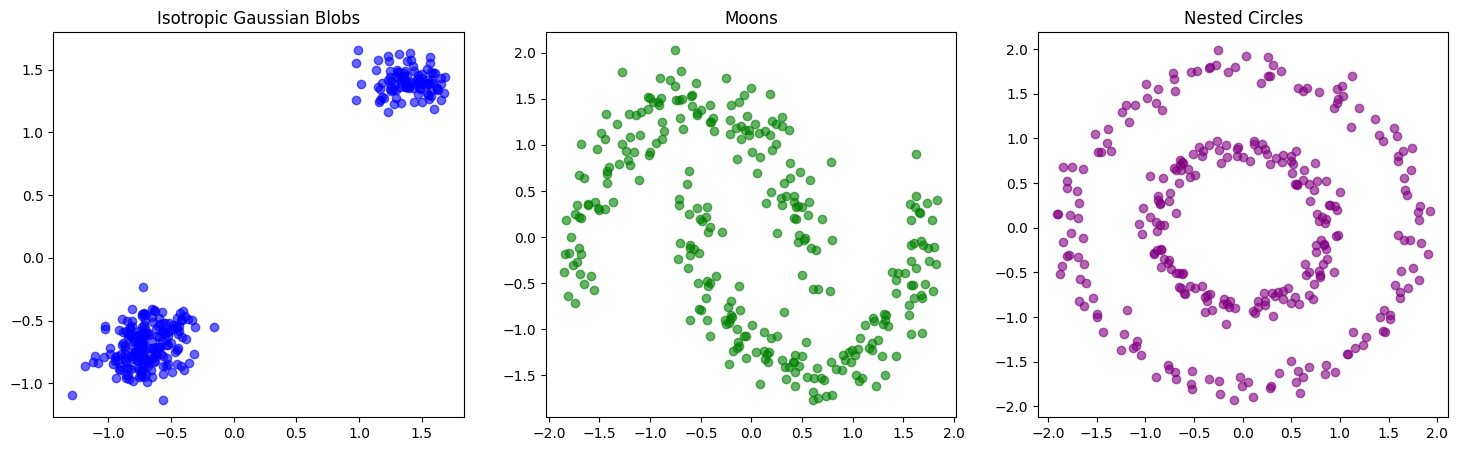

In [12]:
from sklearn.datasets import make_moons, make_blobs, make_circles
from sklearn.preprocessing import StandardScaler

X_blobs, _ = make_blobs(
    n_samples=300, centers=3,
    cluster_std=0.6, random_state=2024
)
X_moons, _ = make_moons(
    n_samples=300, noise=0.1,
    random_state=2024
)
X_circles, _ = make_circles(
    n_samples=300, noise=0.05,
    factor=0.5, random_state=2024
)

X_blobs = StandardScaler().fit_transform(X_blobs)
X_moons = StandardScaler().fit_transform(X_moons)
X_circles = StandardScaler().fit_transform(X_circles)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
axs[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c='blue', alpha=0.6)
axs[0].set_title("Isotropic Gaussian Blobs")
axs[1].scatter(X_moons[:, 0], X_moons[:, 1], c='green', alpha=0.6)
axs[1].set_title("Moons")
axs[2].scatter(X_circles[:, 0], X_circles[:, 1], c='purple', alpha=0.6)
axs[2].set_title("Nested Circles")
plt.show()

These three datasets expose the fundamental assumptions behind different clustering methods:

**Isotropic Gaussian Blobs** (left) -- the classic K-means scenario. Clusters are roughly spherical, well-separated, and similar in size. K-means, hierarchical clustering, and GMMs all perform well here. This is the distribution most often assumed in textbook examples and statistical theory.

**Moons** (center) -- two interleaving crescents. K-means would draw a vertical line through the middle, splitting each crescent in half. Hierarchical clustering with single linkage could handle this (by chaining nearby points along each crescent), but Ward linkage would struggle similarly to K-means. DBSCAN excels here because it follows the density ridge of each crescent regardless of shape.

**Nested Circles** (right) -- a small circle inside a larger one. This is perhaps the most challenging topology for centroid-based methods, since both clusters share the same center. K-means would split the data along a diameter instead of by ring. DBSCAN and spectral clustering can separate these by recognizing the gap in density between the inner and outer rings.

The practical decision guide:

| Data Structure | Best Algorithm | Why |
|---|---|---|
| Convex, equal-sized clusters | K-means | Fast, optimal for isotropic blobs |
| Unknown number of clusters | Hierarchical (dendrogram) | Visual exploration of cluster hierarchy |
| Non-convex shapes, noise present | DBSCAN | Shape-agnostic, built-in noise handling |
| Overlapping, elliptical clusters | GMM | Probabilistic soft assignments |
| Complex manifold structure | Spectral Clustering | Graph-based, handles any topology |

When in doubt, start with K-means (it is fast and gives a baseline), then try DBSCAN if the data looks non-convex, and use hierarchical clustering for exploratory analysis when the number of clusters is uncertain.

## 10.7 Advanced Clustering Techniques

Beyond the three core methods, two advanced algorithms offer additional flexibility for complex data:

**Spectral Clustering** operates on a fundamentally different principle. Rather than working directly in feature space, it:

1. Constructs a **similarity graph** from the data (using nearest neighbors or RBF kernel)
2. Computes the **graph Laplacian** matrix $\mathbf{L} = \mathbf{D} - \mathbf{W}$, where $\mathbf{D}$ is the degree matrix and $\mathbf{W}$ is the adjacency/similarity matrix
3. Finds the $k$ smallest eigenvectors of $\mathbf{L}$ (or the normalized variant)
4. Applies K-means to the eigenvector embedding

This spectral embedding maps data from the original feature space into a space where non-convex clusters become linearly separable. The key idea: if two points are connected by a chain of dense neighbors (even if they are far apart in Euclidean space), the spectral embedding will place them close together.

**Gaussian Mixture Models (GMMs)** provide **soft (probabilistic) clustering**. Instead of assigning each point to exactly one cluster, a GMM models the data as a mixture of $k$ Gaussian distributions:

$$p(\mathbf{x}) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$

where $\pi_k$ is the mixing weight for component $k$ (with $\sum_k \pi_k = 1$), and each component has its own mean $\boldsymbol{\mu}_k$ and covariance $\boldsymbol{\Sigma}_k$. The **Expectation-Maximization (EM)** algorithm iteratively refines these parameters. The key advantage: each point gets a probability of belonging to each cluster, not a hard assignment.

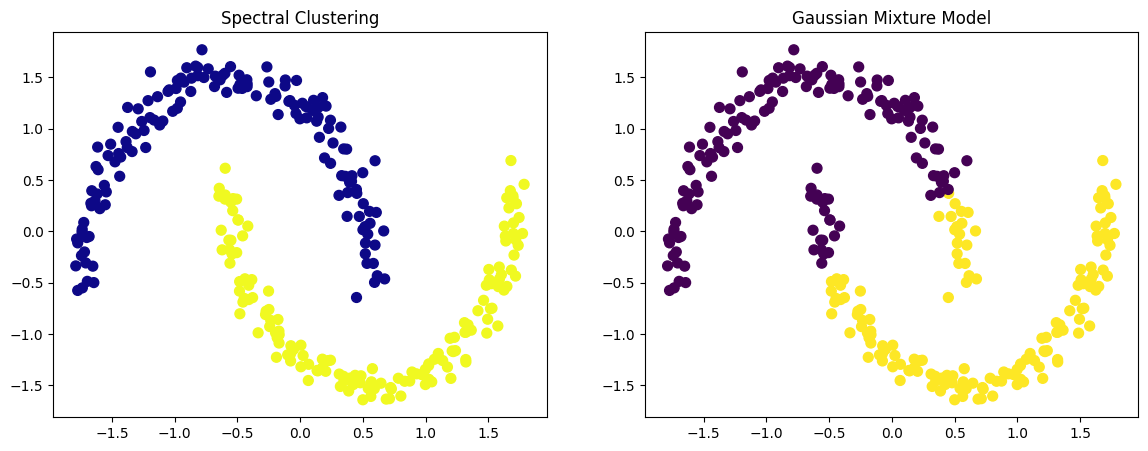

Spectral cluster sizes: [150 150]
GMM cluster sizes: [151 149]


In [13]:
from sklearn.cluster import SpectralClustering
from sklearn.mixture import GaussianMixture

# Use moons data with less noise for cleaner demonstration
X_adv, _ = make_moons(n_samples=300, noise=0.05, random_state=2024)
X_adv = StandardScaler().fit_transform(X_adv)

# Spectral Clustering
spectral = SpectralClustering(
    n_clusters=2,
    affinity='nearest_neighbors',
    random_state=2024
)
y_spectral = spectral.fit_predict(X_adv)

# Gaussian Mixture Model
gmm = GaussianMixture(n_components=2, random_state=2024)
y_gmm = gmm.fit_predict(X_adv)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.scatter(X_adv[:, 0], X_adv[:, 1], c=y_spectral, cmap='plasma', s=50)
ax1.set_title("Spectral Clustering")
ax2.scatter(X_adv[:, 0], X_adv[:, 1], c=y_gmm, cmap='viridis', s=50)
ax2.set_title("Gaussian Mixture Model")
plt.show()

print(f"Spectral cluster sizes: {np.bincount(y_spectral)}")
print(f"GMM cluster sizes: {np.bincount(y_gmm)}")

**Spectral Clustering** perfectly separates the two crescents into balanced clusters of $[150, 150]$. By transforming the data through the graph Laplacian's eigenvectors, the two interleaving moons become linearly separable in the spectral embedding -- allowing the final K-means step to cleanly partition them. This is the power of the spectral approach: it "sees" connectivity, not just distance.

**GMM** produces clusters of $[151, 149]$ -- nearly identical sizes, but the assignment strategy is fundamentally different. Where spectral clustering follows the manifold structure, GMM fits two Gaussian ellipses to the data. For crescent-shaped data, these ellipses are a poor geometric fit, and GMM essentially draws a linear boundary through the data (similar to what K-means would do). The balanced split is somewhat lucky here -- with different random states or noise levels, GMM could misclassify entire sections of a crescent.

This comparison illustrates a crucial principle: **algorithm choice depends on data geometry, not just algorithm sophistication**. Spectral clustering, despite being more computationally expensive ($O(n^3)$ for the eigendecomposition), is the right tool for manifold-structured data. GMM shines when clusters genuinely follow Gaussian distributions with potentially different covariances -- for example, overlapping elliptical clusters where soft probabilistic assignments add real value.

**Production trade-off:** Spectral clustering's $O(n^3)$ cost makes it impractical for datasets larger than $\sim 10{,}000$ points without approximation (e.g., the Nystr\"om method). GMM scales better at $O(nkd^2t)$ per EM iteration, making it feasible for moderately large datasets.

### GMM: Probabilistic Cluster Assignments

One of GMM's most valuable features is `predict_proba()`, which returns the **posterior probability** of each point belonging to each cluster. This enables **uncertainty quantification** -- critical for production systems where downstream decisions depend on cluster assignment confidence.

In [14]:
# Examine cluster probabilities
probs = gmm.predict_proba(X_adv)

print(f"Probability matrix shape: {probs.shape}")
print(f"\nSample probabilities (first 5 points):")
for i in range(5):
    print(f"  Point {i}: P(cluster 0) = {probs[i,0]:.4f}, "
          f"P(cluster 1) = {probs[i,1]:.4f}")

uncertain = np.sum((probs[:, 0] > 0.3) & (probs[:, 0] < 0.7))
print(f"\nPoints with uncertain assignment (0.3 < P < 0.7): {uncertain}")
print(f"GMM converged in {gmm.n_iter_} iterations")
print(f"BIC: {gmm.bic(X_adv):.3f}")
print(f"AIC: {gmm.aic(X_adv):.3f}")

Probability matrix shape: (300, 2)

Sample probabilities (first 5 points):
  Point 0: P(cluster 0) = 0.3780, P(cluster 1) = 0.6220
  Point 1: P(cluster 0) = 0.0474, P(cluster 1) = 0.9526
  Point 2: P(cluster 0) = 0.0005, P(cluster 1) = 0.9995
  Point 3: P(cluster 0) = 1.0000, P(cluster 1) = 0.0000
  Point 4: P(cluster 0) = 0.9999, P(cluster 1) = 0.0001

Points with uncertain assignment (0.3 < P < 0.7): 12
GMM converged in 3 iterations
BIC: 1597.121
AIC: 1556.379


The probability outputs reveal the uncertainty landscape of the GMM solution. Points 2 and 3 have near-certainty ($P > 0.999$) in their assignments -- these sit deep within their respective Gaussian components. Point 0, however, has $P(\text{cluster 0}) = 0.3780$ and $P(\text{cluster 1}) = 0.6220$ -- it sits in the overlap region between the two Gaussians and could plausibly belong to either cluster.

Across all $300$ points, **12 points** ($4\%$) have uncertain assignments (probability between $0.3$ and $0.7$). These are the points near the decision boundary between the two Gaussian components. In a production system, you might treat these uncertain points differently -- flagging them for manual review, assigning them to a "borderline" category, or using the probabilities directly in downstream models rather than committing to a hard cluster label.

The model converged in just **3 EM iterations**, which is fast but expected for a clean $2$-component problem. The **BIC** (Bayesian Information Criterion) of **1,597.121** and **AIC** (Akaike Information Criterion) of **1,556.379** can be used to compare models with different numbers of components: the model with the lowest BIC/AIC is preferred. Running GMM with $k = 1, 2, 3, 4$ components and comparing BIC values is a principled alternative to the elbow method for choosing the number of clusters.

The BIC balances model fit against complexity:

$$\text{BIC} = -2 \ln(\hat{L}) + p \ln(n)$$

where $\hat{L}$ is the maximized likelihood, $p$ is the number of free parameters (for a 2D, 2-component GMM with full covariance: $2$ means $\times 2$ dims $+ 2$ covariance matrices $\times 3$ unique entries $+ 1$ mixing weight $= 11$ parameters), and $n = 300$ samples. The penalty term $p \ln(n)$ grows with model complexity, discouraging unnecessary components.

**Production insight:** GMM's soft assignments are a natural fit for **recommendation systems** and **customer segmentation**. Rather than saying "this customer belongs to segment A," you can say "this customer has a $62\%$ probability of being in segment A and $38\%$ in segment B" -- enabling blended strategies that account for uncertainty. Combined with the BIC for automatic model selection, GMM provides a fully principled clustering pipeline.

## Summary and Key Takeaways

This chapter covered the landscape of clustering -- from the foundational K-means to advanced spectral and probabilistic methods. Here are the key principles to carry forward:

### The Fundamental Trade-offs

| Algorithm | Assumes shape? | Handles noise? | Needs $k$? | Complexity | Soft assignments? |
|---|---|---|---|---|---|
| K-Means | Convex (spherical) | No | Yes | $O(nkdt)$ | No |
| Agglomerative | Depends on linkage | No | Optional | $O(n^2 \log n)$ | No |
| DBSCAN | None | Yes | No | $O(n \log n)$ | No |
| Spectral | None | No | Yes | $O(n^3)$ | No |
| GMM | Elliptical | No | Yes | $O(nk d^2 t)$ | Yes |

### Key Results from This Chapter

On our $300$-point, $4$-blob dataset, K-means achieved an inertia of **7.295** (explaining $98.8\%$ of variance), a silhouette score of **0.534**, and an ARI of **0.814** against the ground truth. These metrics provide complementary views: inertia measures compactness, silhouette measures separation, and ARI measures correctness.

DBSCAN, tested on crescent-moon data, correctly found $2$ non-convex clusters while identifying $4$ noise points -- demonstrating its unique ability to handle arbitrary shapes and flag outliers. Spectral clustering matched this performance on the moons, while GMM struggled because Gaussian ellipses cannot capture crescent geometry.

### Practical Workflow for Clustering

1. **Visualize first.** Plot the raw data (2D directly, higher dimensions with PCA/t-SNE). This guides algorithm choice.
2. **Scale your features.** Distance-based methods (K-means, DBSCAN, hierarchical) are sensitive to feature scales. Always standardize.
3. **Start simple.** K-means with the elbow method gives a fast baseline. If it works well, you may not need anything more complex.
4. **Evaluate with multiple metrics.** No single metric captures clustering quality. Use silhouette score and Davies-Bouldin index together.
5. **Match algorithm to data geometry.** Blobs $\to$ K-means. Crescents $\to$ DBSCAN or Spectral. Unknown structure $\to$ hierarchical dendrogram. Overlapping ellipses $\to$ GMM.

Clustering is inherently more subjective than supervised learning -- there is no single "correct" answer. The best practitioners combine algorithmic understanding with domain expertise and visual inspection to find groupings that are both statistically sound and practically useful.